In [87]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
import pytz
from PIL import Image
from tqdm import tqdm

In [82]:
us_pacific = pytz.timezone('US/Pacific')
utc = pytz.utc

def calculate_sun_center_in_image(timestamp, image_shape):
    date = pd.to_datetime(timestamp, format='%Y%m%d_%H%M%S')
    us_pacific_date = us_pacific.localize(date)
    utc_date = us_pacific_date.astimezone(utc).strftime('%Y%m%d_%H%M%S')
    
    solarposition = pvlib.solarposition.get_solarposition(
        time=pd.to_datetime(utc_date, format='%Y%m%d_%H%M%S'),
        latitude=38.642,
        longitude=-121.148
    )
    zenith = solarposition['zenith'][0]
    azimuth = solarposition['azimuth'][0]

    # compensation of camera orientation
    azimuth -= 165

    R = 2 * 0.48 * np.tan(np.deg2rad(zenith) / 2)

    x_sc = R * np.sin(np.deg2rad(azimuth))
    y_sc = R * np.cos(np.deg2rad(azimuth))

    # convert to the image plane
    x_scp = image_shape[1] / 2 + x_sc * image_shape[1] / 2
    y_scp = image_shape[0] / 2 + y_sc * image_shape[0] / 2

    return int(x_scp), int(y_scp)

In [96]:
timestamp = '20140816_170000'

img_rgb = np.asarray(Image.open(f'./20140816/{timestamp}.jpg')) / 255.
img_grey = np.asarray(Image.open(f'./20140816/{timestamp}.jpg').convert('L')) / 255.
img_hsv = np.asarray(Image.open(f'./20140816/{timestamp}.jpg').convert('HSV')) / 255.

In [97]:
r = img_rgb[..., 0]
g = img_rgb[..., 1]
b = img_rgb[..., 2]

h = img_hsv[..., 0]
s = img_hsv[..., 1]
v = img_hsv[..., 2]
i = img_grey

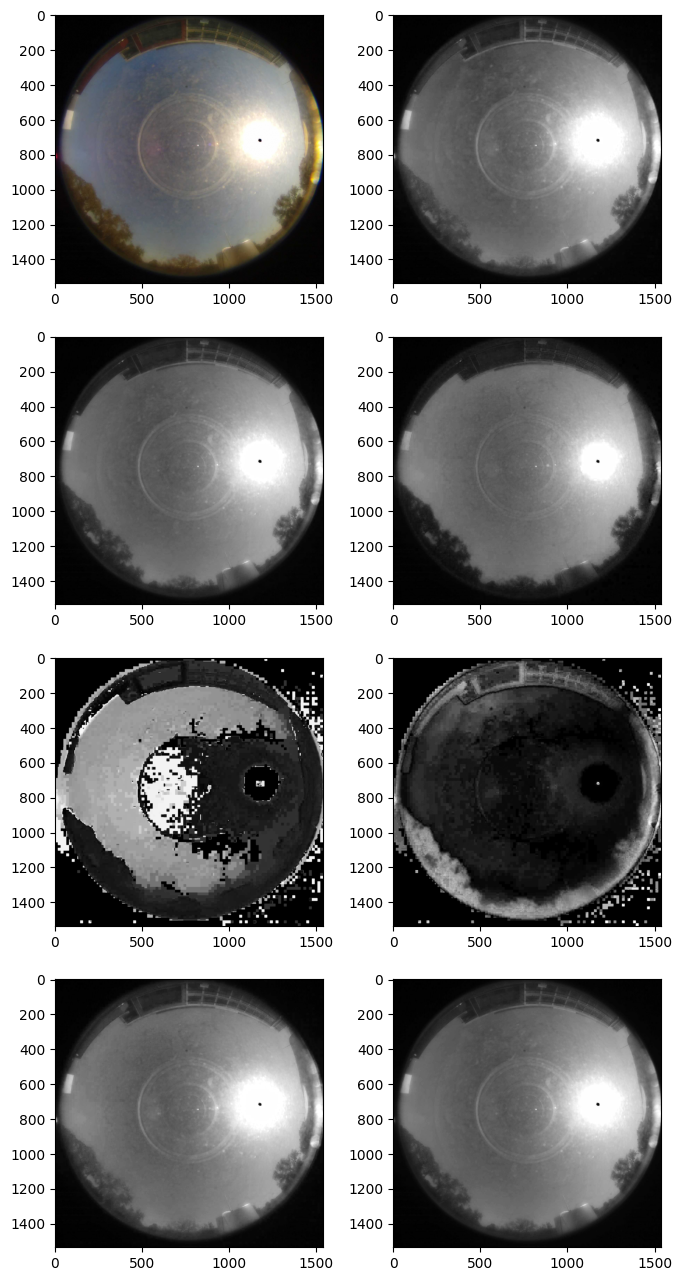

In [98]:
fig, ax = plt.subplots(4, 2, figsize=(8,16))

ax[0][0].imshow(img_rgb)
ax[0][1].imshow(r, cmap='gray', vmax=1, vmin=0)
ax[1][0].imshow(g, cmap='gray', vmax=1, vmin=0)
ax[1][1].imshow(b, cmap='gray', vmax=1, vmin=0)
ax[2][0].imshow(h, cmap='gray', vmax=1, vmin=0)
ax[2][1].imshow(s, cmap='gray', vmax=1, vmin=0)
ax[3][0].imshow(v, cmap='gray', vmax=1, vmin=0)
ax[3][1].imshow(i, cmap='gray', vmax=1, vmin=0)

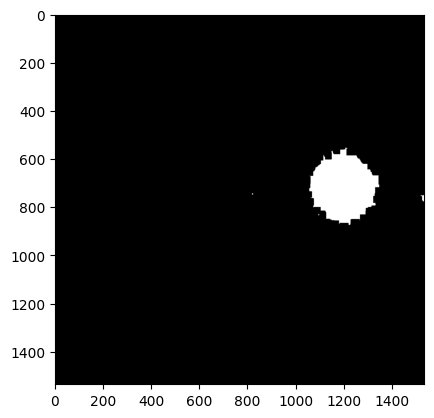

In [99]:
# based on https://www.sciencedirect.com/science/article/pii/S0960148116304529?via%3Dihub
F_s = np.uint8(((r + g + b + v + i) / 5 - (h + s) / 2) > 0.85)

F_s_closing = cv2.morphologyEx(F_s, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=3)
plt.imshow(F_s_closing, cmap='gray', vmax=1)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


1196 719 1163 731


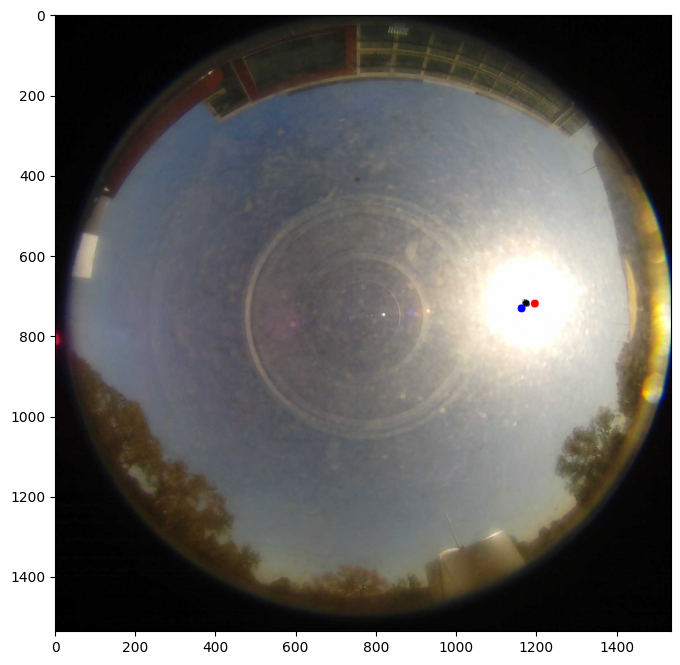

In [101]:
img_with_sun_center = img_rgb.copy()

contours, hierarchy = cv2.findContours(F_s_closing, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
max_cnt = sorted(contours, key=cv2.contourArea)[-1]

M = cv2.moments(max_cnt)
cX = int(M["m10"] / M["m00"])
cY = int(M["m01"] / M["m00"])

cv2.circle(img_with_sun_center, (cX, cY), 10, (255, 0, 0), -1)

sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536))
cv2.circle(img_with_sun_center, (sX, sY), 10, (0, 0, 255), -1)

print(cX, cY, sX, sY)

fig = plt.figure(figsize=(8,8))
plt.imshow(img_with_sun_center)

In [90]:
pred_x = []
pred_y = []
pvlib_x = []
pvlib_y = []

for timestamp in tqdm(sorted(Path('./20140816/').glob('*.jpg'))):
    timestamp = timestamp.stem
    img_rgb = np.asarray(Image.open(f'./20140816/{timestamp}.jpg')) / 255.
    img_grey = np.asarray(Image.open(f'./20140816/{timestamp}.jpg').convert('L')) / 255.
    img_hsv = np.asarray(Image.open(f'./20140816/{timestamp}.jpg').convert('HSV')) / 255.
    
    r = img_rgb[..., 0]
    g = img_rgb[..., 1]
    b = img_rgb[..., 2]

    h = img_hsv[..., 0]
    s = img_hsv[..., 1]
    v = img_hsv[..., 2]
    i = img_grey
    
    F_s = np.uint8(((r + g + b + v + i) / 5 - (h + s) / 2) > 0.85)

    F_s_closing = cv2.morphologyEx(F_s, cv2.MORPH_CLOSE, np.ones((9, 9), np.uint8), iterations=3)

    contours, hierarchy = cv2.findContours(F_s_closing, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) < 1:
        continue
    max_cnt = sorted(contours, key=cv2.contourArea)[-1]

    M = cv2.moments(max_cnt)
    cX = int(M["m10"] / M["m00"])
    cY = int(M["m01"] / M["m00"])
    pred_x.append(cX)
    pred_y.append(cY)

    sX, sY = calculate_sun_center_in_image(timestamp, (1536, 1536))
    pvlib_x.append(sX)
    pvlib_y.append(sY)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 809/809 [01:16<00:00, 10.53it/s]


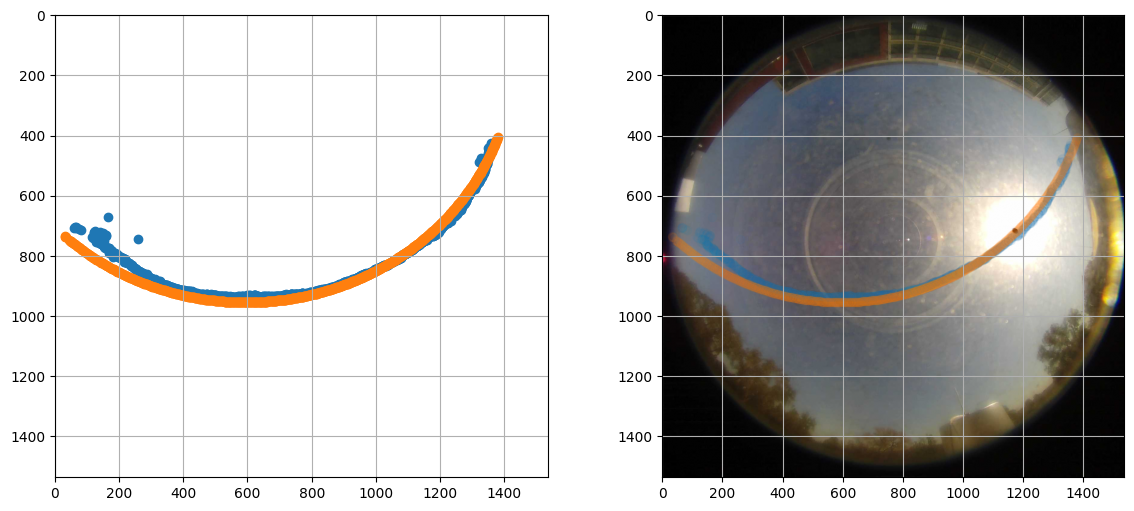

In [114]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ax[0].scatter(x=pred_x, y=pred_y)
ax[0].scatter(x=pvlib_x, y=pvlib_y)
ax[0].set_xlim((0, 1536))
ax[0].set_ylim((1536, 0))
ax[0].grid(True)

ax[1].imshow(img_rgb)
ax[1].scatter(x=pred_x, y=pred_y, alpha=0.05)
ax[1].scatter(x=pvlib_x, y=pvlib_y, alpha=0.05)
ax[1].set_xlim((0, 1536))
ax[1].set_ylim((1536, 0))
ax[1].grid(True)